In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
def load_and_prepare_data():

    transaction_df = pd.read_csv("cleaned_transaction.csv")

    transaction_df["Date"] = pd.to_datetime(transaction_df["Date"])

    daily_sales = (
        transaction_df.groupby("Date")["Amount"]
        .sum()
        .asfreq("D")
    )

    daily_sales = daily_sales.interpolate()

    daily_sales = daily_sales.reset_index()

    return daily_sales

In [3]:
def add_features(daily_sales):

    daily_sales["lag_1"] = daily_sales["Amount"].shift(1)
    daily_sales["lag_7"] = daily_sales["Amount"].shift(7)

    daily_sales["rolling_mean_7"] = daily_sales["Amount"].rolling(7).mean()

    daily_sales["day_of_week"] = daily_sales["Date"].dt.dayofweek
    daily_sales["month"] = daily_sales["Date"].dt.month

    daily_sales["is_weekend"] = (daily_sales["day_of_week"] >= 5).astype(int)

    daily_sales.dropna(inplace=True)

    daily_sales = daily_sales.iloc[:-1]

    return daily_sales

In [4]:
def scale_data(daily_sales):

    features = [
        "Amount",
        "lag_1",
        "lag_7",
        "rolling_mean_7",
        "day_of_week",
        "is_weekend"
    ]

    data = daily_sales[features].values

    scaler = MinMaxScaler()

    scaled_data = scaler.fit_transform(data)

    joblib.dump(scaler, "scaler.pkl")

    return scaled_data, scaler

In [5]:
def create_sequences(data, window=5):

    X = []
    y = []

    for i in range(len(data) - window):

        X.append(data[i:i+window])
        y.append(data[i+window][0])

    return np.array(X), np.array(y)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization

def build_model(input_shape):

    model = Sequential()

    # Layer 1
    model.add(Bidirectional(
        LSTM(64, return_sequences=True),
        input_shape=input_shape
    ))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Layer 2
    model.add(Bidirectional(
        LSTM(32, return_sequences=True)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Layer 3
    model.add(LSTM(16))
    model.add(Dropout(0.2))

    # Dense layers
    model.add(Dense(16, activation="relu"))
    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

In [7]:
def train_model(X_train, y_train, X_test, y_test):

    model = build_model((X_train.shape[1], X_train.shape[2]))

    early_stop = EarlyStopping(patience=10, restore_best_weights=True)

    history = model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=16,
        validation_data=(X_test, y_test),
        callbacks=[early_stop]
    )

    model.save("sales_lstm_model.h5")

    return model, history

In [8]:
def evaluate_model(model, X_test, y_test, scaler, feature_count):

    test_pred = model.predict(X_test)

    pred_full = np.zeros((len(test_pred), feature_count))
    pred_full[:,0] = test_pred.flatten()

    pred_actual = scaler.inverse_transform(pred_full)[:,0]

    y_full = np.zeros((len(y_test), feature_count))
    y_full[:,0] = y_test

    y_actual = scaler.inverse_transform(y_full)[:,0]

    rmse = np.sqrt(mean_squared_error(y_actual, pred_actual))
    mae = mean_absolute_error(y_actual, pred_actual)

    print("RMSE:", rmse)
    print("MAE:", mae)

    plt.figure(figsize=(10,5))
    plt.plot(y_actual, label="Actual")
    plt.plot(pred_actual, label="Predicted")
    plt.legend()
    plt.title("Actual vs Predicted Sales")
    plt.show()

In [9]:
def predict_future_sales(model, scaled_data, scaler, window=30, days=30):

    temp_input = scaled_data[-window:].tolist()

    predictions = []

    for i in range(days):

        x_input = np.array(temp_input[-window:])
        x_input = x_input.reshape(1, window, len(temp_input[0]))

        pred = model.predict(x_input, verbose=0)[0][0]

        predictions.append(pred)

        new_row = temp_input[-1].copy()
        new_row[0] = pred

        temp_input.append(new_row)

    pred_array = np.zeros((days, scaled_data.shape[1]))
    pred_array[:,0] = predictions

    predictions_actual = scaler.inverse_transform(pred_array)[:,0]

    return predictions_actual

Epoch 1/100


c:\Users\kichu\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 451ms/step - loss: 0.3499 - val_loss: 0.1001
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0563 - val_loss: 0.0906
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0505 - val_loss: 0.0821
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0448 - val_loss: 0.0759
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0451 - val_loss: 0.0713
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0386 - val_loss: 0.0671
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0309 - val_loss: 0.0608
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0348 - val_loss: 0.0542
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0255 - val_loss: 0.0463
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0185 - val_loss: 0.0396
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0175 - val_loss: 0.0342
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0241 - val_loss: 0.0295


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step
RMSE: 51223.86157733457
MAE: 43755.94038029691


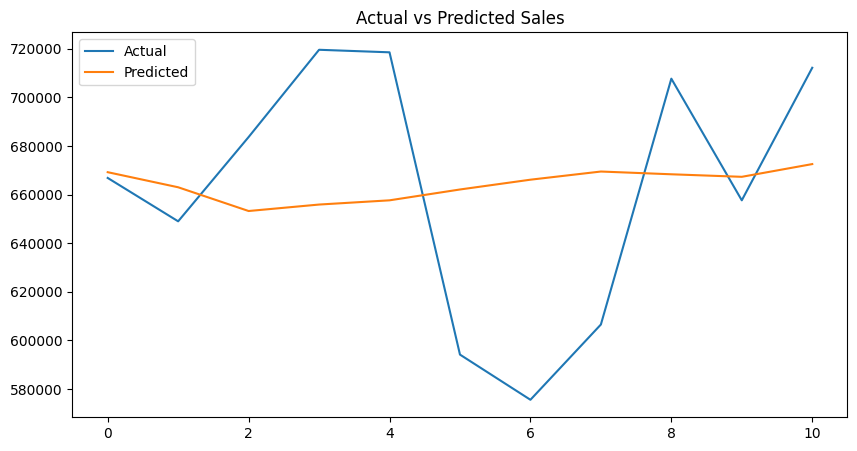

Next 30 days sales prediction:
[675702.55438221 679381.45301545 682657.09288397 685478.58787501
 687843.28147495 689636.80879077 690583.96294326 690665.39499751
 690585.46169272 690267.73473608 689797.97590253 689237.17398641
 688657.22931257 687740.0342896  686810.36554754 686444.32969281
 686237.43882754 685995.07755828 685703.30513602 685430.54066333
 684975.00805485 684460.53256398 684356.4923895  684222.16795996
 684103.346468   683922.30704853 683691.43619183 683307.86734733
 682966.55689383 683032.40671158]


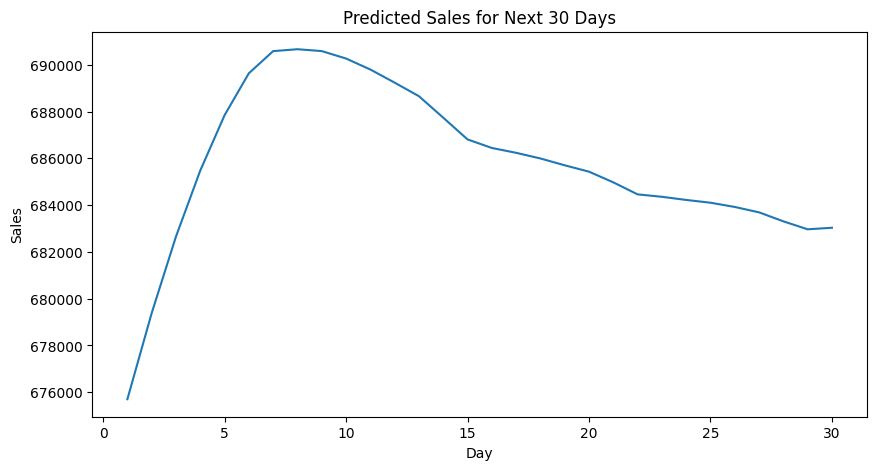

In [10]:
daily_sales = load_and_prepare_data()

daily_sales = add_features(daily_sales)

scaled_data, scaler = scale_data(daily_sales)

X, y = create_sequences(scaled_data, 30)

train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

model, history = train_model(X_train, y_train, X_test, y_test)

evaluate_model(model, X_test, y_test, scaler, scaled_data.shape[1])

future_predictions = predict_future_sales(model, scaled_data, scaler)

print("Next 30 days sales prediction:")
print(future_predictions)

plt.figure(figsize=(10,5))
plt.plot(range(1,31), future_predictions)
plt.title("Predicted Sales for Next 30 Days")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.show()

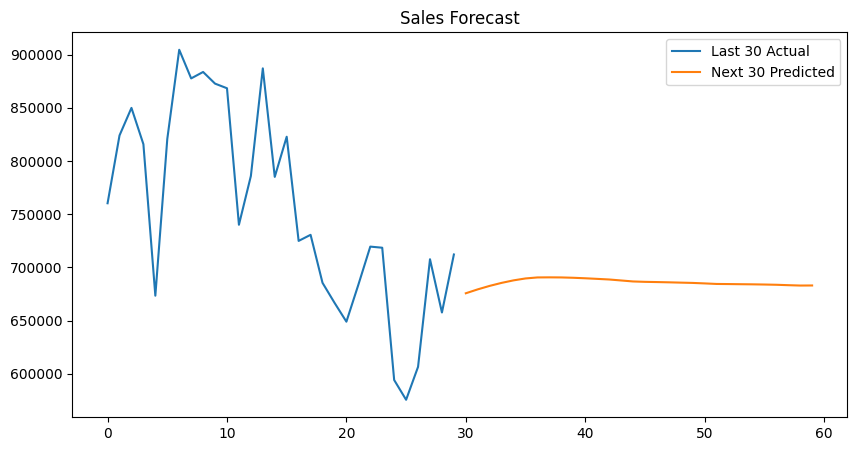

In [11]:
plt.figure(figsize=(10,5))

plt.plot(daily_sales["Amount"].tail(30).values, label="Last 30 Actual")

future_index = range(30, 60)
plt.plot(future_index, future_predictions, label="Next 30 Predicted")

plt.legend()
plt.title("Sales Forecast")
plt.show()

In [12]:
print(daily_sales.tail(10))

         Date    Amount     lag_1     lag_7  rolling_mean_7  day_of_week  \
80 2022-06-19  649002.0  666842.0  887092.0   723550.428571            6   
81 2022-06-20  683667.0  649002.0  785093.0   709061.000000            0   
82 2022-06-21  719559.0  683667.0  822843.0   694306.142857            1   
83 2022-06-22  718515.0  719559.0  724919.0   693391.285714            2   
84 2022-06-23  594183.0  718515.0  730645.0   673896.714286            3   
85 2022-06-24  575599.0  594183.0  685509.0   658195.285714            4   
86 2022-06-25  606554.0  575599.0  666842.0   649582.714286            5   
87 2022-06-26  707677.0  606554.0  649002.0   657964.857143            6   
88 2022-06-27  657638.0  707677.0  683667.0   654246.428571            0   
89 2022-06-28  712159.0  657638.0  719559.0   653189.285714            1   

    month  is_weekend  
80      6           1  
81      6           0  
82      6           0  
83      6           0  
84      6           0  
85      6          

In [13]:
# import joblib

# model.save("lstm_sales_model.h5")
# joblib.dump(scaler,"scaler.pkl")